In [146]:
#AI-Driven Screening for Carbon Capture Materials
#Predicting CO₂ Uptake in Metal-Organic Frameworks (MOFs)
#Goal: Build a machine learning model that predicts CO₂ uptake capacity of a MOF purely from its geometric structure — enabling rapid screening of 90,000+ candidates without expensive lab experiments.

In [147]:
#Step 1 — Imports for EDA

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

In [148]:
#Step 2 — Load Data

df=pd.read_csv(r"C:\Users\kvgir\Downloads\all_MOFs_screening_data.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (324426, 42)
Columns: ['MOFname', 'CO2_uptake_P0.15bar_T298K [mmol/g]', 'CO2_uptake_error_P0.15bar_T298K [mmol/g]', 'heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]', 'heat_adsorption_error_CO2_P0.15bar_T298K [kcal/mol]', 'excess_CO2_uptake_P0.15bar_T298K [mmol/g]', 'CO2_uptake_P0.10bar_T363K [mmol/g]', 'CO2_uptake_error_P0.10bar_T363K [mmol/g]', 'heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]', 'heat_adsorption_error_CO2_P0.10bar_T363K [kcal/mol]', 'excess_CO2_uptake_P0.10bar_T363K [mmol/g]', 'CO2_uptake_P0.70bar_T413K [mmol/g]', 'CO2_uptake_error_P0.70bar_T413K [mmol/g]', 'heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]', 'heat_adsorption_error_CO2_P0.70bar_T413K [kcal/mol]', 'excess_CO2_uptake_P0.70bar_T413K [mmol/g]', 'working_capacity_vacuum_swing [mmol/g]', 'working_capacity_temperature_swing [mmol/g]', 'CO2_binary_uptake_P0.15bar_T298K [mmol/g]', 'CO2_binary_uptake_error_P0.15bar_T298K [mmol/g]', 'heat_adsorption_CO2_binary_P0.15bar_T298K [kcal/mol]', 'heat_adsorption_error_CO

In [149]:
#Step 3 — Basic Inspection
#Check data types and first few rows to understand what each column represents.

df.head()
df.dtypes

MOFname                                                         object
CO2_uptake_P0.15bar_T298K [mmol/g]                             float64
CO2_uptake_error_P0.15bar_T298K [mmol/g]                       float64
heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]                  float64
heat_adsorption_error_CO2_P0.15bar_T298K [kcal/mol]            float64
excess_CO2_uptake_P0.15bar_T298K [mmol/g]                      float64
CO2_uptake_P0.10bar_T363K [mmol/g]                             float64
CO2_uptake_error_P0.10bar_T363K [mmol/g]                       float64
heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]                  float64
heat_adsorption_error_CO2_P0.10bar_T363K [kcal/mol]            float64
excess_CO2_uptake_P0.10bar_T363K [mmol/g]                      float64
CO2_uptake_P0.70bar_T413K [mmol/g]                             float64
CO2_uptake_error_P0.70bar_T413K [mmol/g]                       float64
heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]                  float64
heat_a

In [150]:
#Step 4 — Missing Values
#Identify which columns have nulls and what percentage of data is affected.

missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': pct
})

print(missing_df[missing_df['missing_count'] > 0])

                                                    missing_count  missing_pct
heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]                2087         0.64
heat_adsorption_error_CO2_P0.15bar_T298K [kcal/...           2087         0.64
heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]                2094         0.65
heat_adsorption_error_CO2_P0.10bar_T363K [kcal/...           2094         0.65
CO2_uptake_P0.70bar_T413K [mmol/g]                            167         0.05
CO2_uptake_error_P0.70bar_T413K [mmol/g]                      167         0.05
heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]                2100         0.65
heat_adsorption_error_CO2_P0.70bar_T413K [kcal/...           2100         0.65
excess_CO2_uptake_P0.70bar_T413K [mmol/g]                     167         0.05
heat_adsorption_CO2_binary_P0.15bar_T298K [kcal...           2477         0.76
heat_adsorption_error_CO2_binary_P0.15bar_T298K...           2477         0.76
heat_adsorption_N2_binary_P0.85bar_T298K [kcal/...  

c:\Users\kvgir\AppData\Local\Programs\Python\Python36\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 8322 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\kvgir\AppData\Local\Programs\Python\Python36\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 8322 missing from current font.
  font.set_text(s, 0, flags=flags)


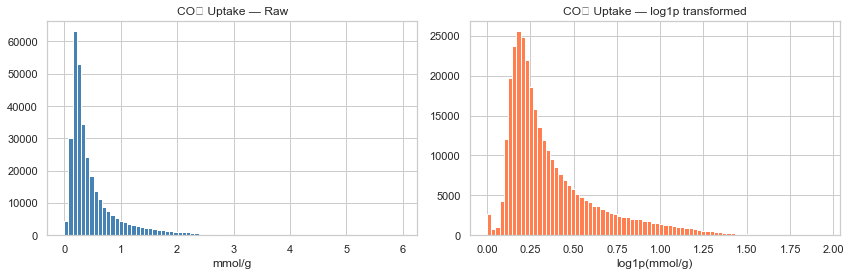

count    324426.000000
mean          0.517388
std           0.532612
min           0.000000
25%           0.204142
50%           0.319068
75%           0.605401
max           5.955197
Name: CO2_uptake_P0.15bar_T298K [mmol/g], dtype: float64


In [151]:
#Step 5 — Target Variable Distribution
#Our target is CO2_uptake_P0.15bar_T298K — CO₂ uptake at standard flue gas conditions (0.15 bar, 298 K). We check if it's skewed — skewed targets are harder to predict and may need a log transform later.

TARGET = 'CO2_uptake_P0.15bar_T298K [mmol/g]'

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df[TARGET].hist(bins=80, color='steelblue', edgecolor='white')
plt.title('CO₂ Uptake — Raw')
plt.xlabel('mmol/g')

plt.subplot(1, 2, 2)
np.log1p(df[TARGET]).hist(bins=80, color='coral', edgecolor='white')
plt.title('CO₂ Uptake — log1p transformed')
plt.xlabel('log1p(mmol/g)')

plt.tight_layout()
plt.show()

print(df[TARGET].describe())

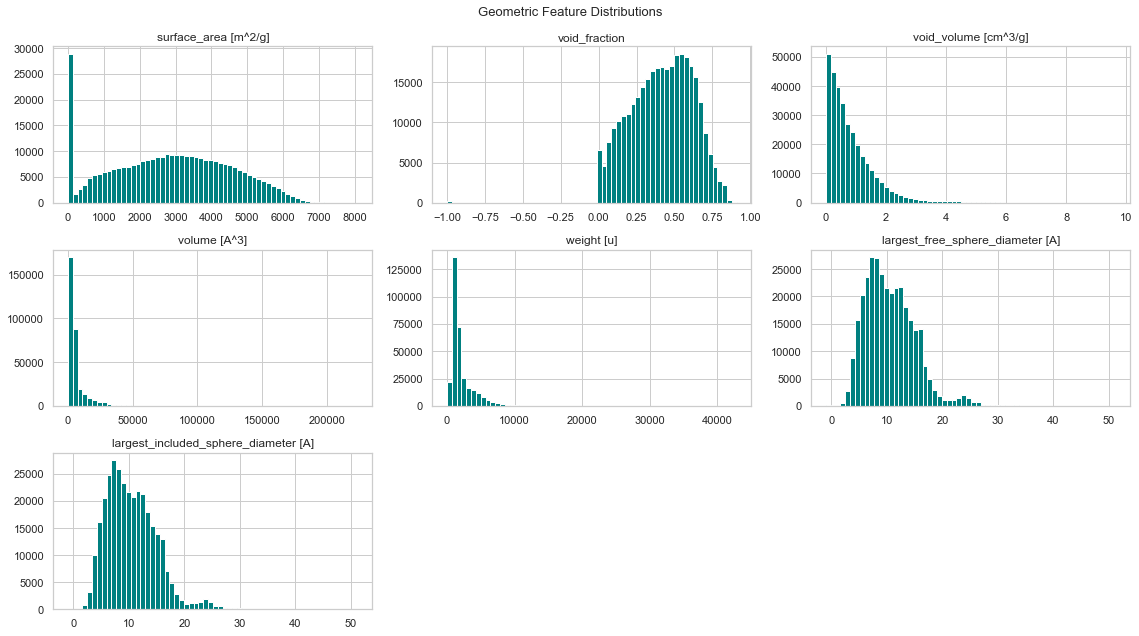

In [152]:
#Step 6 — Geometric Feature Distributions
#These are the structural descriptors we will use as model inputs.

geo_cols = [
    'surface_area [m^2/g]', 'void_fraction',
    'void_volume [cm^3/g]', 'volume [A^3]', 'weight [u]',
    'largest_free_sphere_diameter [A]',
    'largest_included_sphere_diameter [A]'
]

df[geo_cols].hist(bins=60, figsize=(16, 9), color='teal', edgecolor='white')
plt.suptitle('Geometric Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

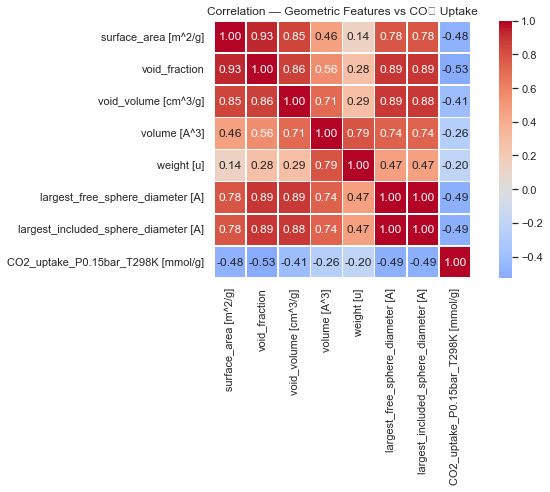

In [153]:
#Step 7 — Correlation Heatmap
#Shows how strongly each geometric feature correlates with CO₂ uptake.Values close to +1 or -1 = strong relationship with target.

corr_cols = geo_cols + [TARGET]

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('Correlation — Geometric Features vs CO₂ Uptake')
plt.tight_layout()
plt.show()

In [154]:
#Step 8 — Categorical Columns Overview
#Check how many unique values each categorical column has — this decides which encoding strategy we use later.

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print("{col:30s} → {df[col].nunique()} unique values")

{col:30s} → {df[col].nunique()} unique values
{col:30s} → {df[col].nunique()} unique values
{col:30s} → {df[col].nunique()} unique values


In [155]:
#Step 9 — Data Cleaning
# Drop Error / Uncertainty Columns

error_cols = [c for c in df.columns if 'error' in c.lower()]
print("Dropping:", error_cols)
df = df.drop(columns=error_cols)
print("\nShape after dropping error cols:", df.shape)

df=df.drop(["heat_adsorption_CO2_P0.15bar_T298K [kcal/mol]","excess_CO2_uptake_P0.15bar_T298K [mmol/g]","CO2_uptake_P0.10bar_T363K [mmol/g]","heat_adsorption_CO2_P0.10bar_T363K [kcal/mol]","excess_CO2_uptake_P0.10bar_T363K [mmol/g]","CO2_uptake_P0.70bar_T413K [mmol/g]","heat_adsorption_CO2_P0.70bar_T413K [kcal/mol]","excess_CO2_uptake_P0.70bar_T413K [mmol/g]","CO2_binary_uptake_P0.15bar_T298K [mmol/g]","heat_adsorption_CO2_binary_P0.15bar_T298K [kcal/mol]","excess_CO2_binary_uptake_P0.15bar_T298K [mmol/g]","N2_binary_uptake_P0.85bar_T298K [mmol/g]","heat_adsorption_N2_binary_P0.85bar_T298K [kcal/mol]","excess_N2_binary_uptake_P0.85bar_T298K [mmol/g]","working_capacity_temperature_swing [mmol/g]","working_capacity_vacuum_swing [mmol/g]", "CO2/N2_selectivity"],axis=1)
df.columns
df.shape

#Handle Missing Values
df.dropna(inplace=True)

print("Final shape:", df.shape)
print("Null values remaining:", df.isnull().sum().sum())
print("\nRemaining columns:")
print(df.columns.tolist())

Dropping: ['CO2_uptake_error_P0.15bar_T298K [mmol/g]', 'heat_adsorption_error_CO2_P0.15bar_T298K [kcal/mol]', 'CO2_uptake_error_P0.10bar_T363K [mmol/g]', 'heat_adsorption_error_CO2_P0.10bar_T363K [kcal/mol]', 'CO2_uptake_error_P0.70bar_T413K [mmol/g]', 'heat_adsorption_error_CO2_P0.70bar_T413K [kcal/mol]', 'CO2_binary_uptake_error_P0.15bar_T298K [mmol/g]', 'heat_adsorption_error_CO2_binary_P0.15bar_T298K [kcal/mol]', 'N2_binary_uptake_error_P0.85bar_T298K [mmol/g]', 'heat_adsorption_error_N2_binary_P0.85bar_T298K [kcal/mol]']

Shape after dropping error cols: (324426, 32)
Final shape: (322429, 15)
Null values remaining: 0

Remaining columns:
['MOFname', 'CO2_uptake_P0.15bar_T298K [mmol/g]', 'volume [A^3]', 'weight [u]', 'surface_area [m^2/g]', 'void_fraction', 'void_volume [cm^3/g]', 'largest_free_sphere_diameter [A]', 'largest_included_sphere_along_free_sphere_path_diameter [A]', 'largest_included_sphere_diameter [A]', 'functional_groups', 'metal_linker', 'organic_linker1', 'organic_l

In [156]:
#Step 10 — Encoding Categorical Columns
#Machine learning models only understand numbers. We have 3 categorical columns, each needing a different strategy.

df=pd.get_dummies(df,columns=["topology","metal_linker"])

bool_cols=df.select_dtypes(include="bool").columns
df[bool_cols]=df[bool_cols].astype(int)
df.dtypes

MOFname                                                         object
CO2_uptake_P0.15bar_T298K [mmol/g]                             float64
volume [A^3]                                                   float64
weight [u]                                                     float64
surface_area [m^2/g]                                           float64
void_fraction                                                  float64
void_volume [cm^3/g]                                           float64
largest_free_sphere_diameter [A]                               float64
largest_included_sphere_along_free_sphere_path_diameter [A]    float64
largest_included_sphere_diameter [A]                           float64
functional_groups                                               object
organic_linker1                                                  int64
organic_linker2                                                  int64
topology_acs                                                     uint8
topolo

In [157]:
#Step 11 — Feature Engineering
#We create new features from existing geometric columns.

# Surface area packed per unit volume
df['sa_per_volume'] = df['surface_area [m^2/g]'] / (df['volume [A^3]'] + 1e-9)

# How dense the pores are relative to pore size
df['pore_density'] = df['void_fraction'] / (df['largest_included_sphere_diameter [A]'] + 1e-9)

# Combined adsorption capacity proxy
df['void_x_sa'] = df['void_volume [cm^3/g]'] * df['surface_area [m^2/g]']

print("New shape:", df.shape)

New shape: (322429, 34)


In [158]:
#Step 12 — Define X and y
#Separate the dataset into:

#x — all input features (geometry + encoded categoricals)
#y — target variable (CO₂ uptake)
#Why log1p transform on y?
#The target is right-skewed — most MOFs have low uptake but a few have very high values. It helped us to increase the r2 score.

TARGET = "CO2_uptake_P0.15bar_T298K [mmol/g]"
y=df[TARGET]
x=df.drop(columns=[TARGET])
x=x.select_dtypes(include="number")
print("x.shape: ",x.shape)
print("y.shape: ",y.shape)
print("\nFeatures going into model: ")
print(x.columns.tolist())

# Log transform target
y_log = np.log1p(y)

x.shape:  (322429, 31)
y.shape:  (322429,)

Features going into model: 
['volume [A^3]', 'weight [u]', 'surface_area [m^2/g]', 'void_fraction', 'void_volume [cm^3/g]', 'largest_free_sphere_diameter [A]', 'largest_included_sphere_along_free_sphere_path_diameter [A]', 'largest_included_sphere_diameter [A]', 'organic_linker1', 'organic_linker2', 'topology_acs', 'topology_bcu', 'topology_etb', 'topology_fof', 'topology_nbo', 'topology_pcu', 'topology_pts', 'topology_rht', 'topology_sra', 'topology_tbo', 'topology_the', 'metal_linker_1', 'metal_linker_2', 'metal_linker_3', 'metal_linker_4', 'metal_linker_9', 'metal_linker_10', 'metal_linker_12', 'sa_per_volume', 'pore_density', 'void_x_sa']


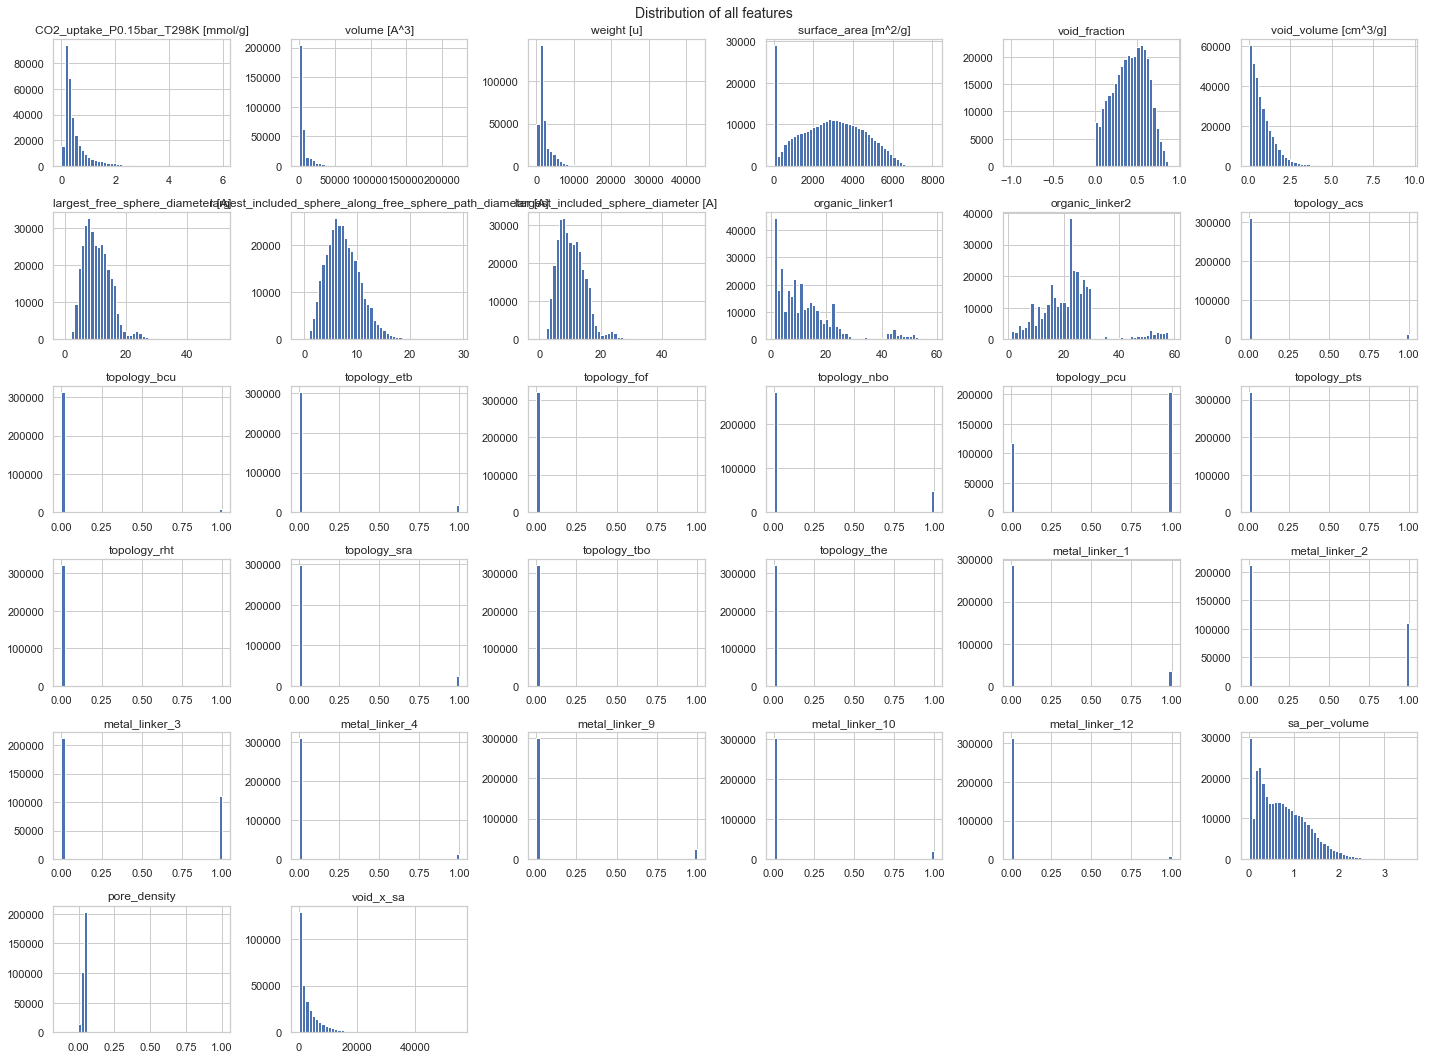

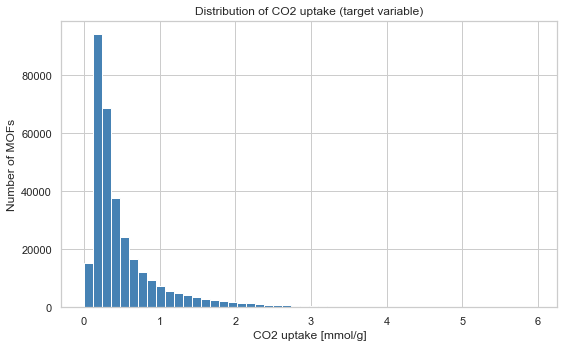

In [159]:
df.hist(bins=50,figsize=(20,15))
plt.suptitle("Distribution of all features",fontsize=14)
plt.tight_layout()
plt.show()
plt.figure(figsize=(8,5))
plt.hist(df["CO2_uptake_P0.15bar_T298K [mmol/g]"],bins=50,color="steelblue")
plt.xlabel("CO2 uptake [mmol/g]")
plt.ylabel("Number of MOFs")
plt.title("Distribution of CO2 uptake (target variable)")
plt.tight_layout()
plt.show()


In [160]:
#Step 13 — Train / Validation / Test Split (70 / 15 / 15)
#Three separate sets:

#Train (70%) — model learns from this
#Validation (15%) — monitors overfitting during training via early stopping
#Test (15%) — completely untouched until final evaluation

from sklearn.model_selection import train_test_split
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y_log,
    test_size=0.30,   
    random_state=42
)
x_test, x_val, y_test, y_val = train_test_split(
    x_temp, y_temp,
    test_size=0.50,
    random_state=42
)
print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)
print(len(x_train) / len(x))  
print(len(x_val) / len(x))    
print(len(x_test) / len(x))   

freq = df['functional_groups'].value_counts()
df['functional_groups_encoded'] = df['functional_groups'].map(freq)
df.drop('functional_groups', axis=1, inplace=True)

Train: (225700, 31)
Validation: (48365, 31)
Test: (48364, 31)
0.6999990695626014
0.15000201594769702
0.1499989144897016


In [161]:
#Step 14 — StandardScaler
#Transforms each feature to mean=0 and std=1.

from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

In [162]:
#Step 15 — XGBoost Model Training

from xgboost import XGBRegressor
model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=5,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    colsample_bylevel=0.7,
    reg_alpha=1.0,
    reg_lambda=5.0,
    gamma=0.1,                 
    random_state=42,
    n_jobs=-1
)

model.fit(
    x_train_scaled, y_train,
    eval_set=[(x_test_scaled, y_test)],
    early_stopping_rounds=190,
    verbose=50
)

[0]	validation_0-rmse:0.29923
[50]	validation_0-rmse:0.22715
[100]	validation_0-rmse:0.18870
[150]	validation_0-rmse:0.16802
[200]	validation_0-rmse:0.15524
[250]	validation_0-rmse:0.14677
[300]	validation_0-rmse:0.14040
[350]	validation_0-rmse:0.13532
[400]	validation_0-rmse:0.13142
[450]	validation_0-rmse:0.12848
[500]	validation_0-rmse:0.12558
[550]	validation_0-rmse:0.12335
[600]	validation_0-rmse:0.12146
[650]	validation_0-rmse:0.11986
[700]	validation_0-rmse:0.11843
[750]	validation_0-rmse:0.11725
[800]	validation_0-rmse:0.11621
[850]	validation_0-rmse:0.11528
[900]	validation_0-rmse:0.11437
[950]	validation_0-rmse:0.11366
[1000]	validation_0-rmse:0.11301
[1050]	validation_0-rmse:0.11238
[1100]	validation_0-rmse:0.11183
[1150]	validation_0-rmse:0.11129
[1200]	validation_0-rmse:0.11081
[1250]	validation_0-rmse:0.11039
[1300]	validation_0-rmse:0.10991
[1350]	validation_0-rmse:0.10955
[1400]	validation_0-rmse:0.10919
[1450]	validation_0-rmse:0.10884
[1500]	validation_0-rmse:0.10848


XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=0.7,
             colsample_bynode=1, colsample_bytree=0.7, enable_categorical=False,
             gamma=0.1, gpu_id=-1, importance_type=None,
             interaction_constraints='', learning_rate=0.01, max_delta_step=0,
             max_depth=5, min_child_weight=5, missing=nan,
             monotone_constraints='()', n_estimators=2000, n_jobs=-1,
             num_parallel_tree=1, predictor='auto', random_state=42,
             reg_alpha=1.0, reg_lambda=5.0, scale_pos_weight=1, subsample=0.7,
             tree_method='exact', validate_parameters=1, verbosity=None)

In [ ]:
feature_importance = pd.DataFrame({
    'feature': x.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance.head(20))

important_features = feature_importance[feature_importance['importance'] > 0.001]['feature'].tolist()
print("Keeping {len(important_features)} of {len(x.columns)} features")

x_train_selected = x_train[important_features]
x_val_selected = x_val[important_features]
x_test_selected = x_test[important_features]

scaler_new = StandardScaler()
x_train_sel_scaled = scaler_new.fit_transform(x_train_selected)
x_val_sel_scaled = scaler_new.transform(x_val_selected)
x_test_sel_scaled = scaler_new.transform(x_test_selected)

model_new = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=5,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    colsample_bylevel=0.7,
    reg_alpha=1.0,
    reg_lambda=5.0,
    gamma=0.1,
    random_state=42,
    n_jobs=-1
)

model_new.fit(
    x_train_sel_scaled, y_train,
    eval_set=[(x_test_sel_scaled, y_test)],
    early_stopping_rounds=50,
    verbose=50
)

                                              feature  importance
12                                       topology_etb    0.156016
7                largest_included_sphere_diameter [A]    0.114231
26                                    metal_linker_10    0.104956
3                                       void_fraction    0.087722
13                                       topology_fof    0.085644
5                    largest_free_sphere_diameter [A]    0.068383
11                                       topology_bcu    0.039140
27                                    metal_linker_12    0.035395
6   largest_included_sphere_along_free_sphere_path...    0.031154
21                                     metal_linker_1    0.030684
4                                void_volume [cm^3/g]    0.030377
14                                       topology_nbo    0.028185
8                                     organic_linker1    0.027813
9                                     organic_linker2    0.024161
30        

In [ ]:
#Step 16 — Predictions
#We predict on all three sets to check for overfitting.

#Since we trained on log1p(y) we must reverse with expm1() before computing metrics — this gives R² on the original mmol/g scale.

y_pred_log=model_new.predict(x_test_sel_scaled)
y_pred=np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)
y_train_pred_log = model_new.predict(x_train_sel_scaled)

y_train_pred = np.expm1(y_train_pred_log)
y_train_actual = np.expm1(y_train)

In [ ]:
#Step 17 — Evaluation Metrics
#We evaluate using three metrics:

#R² — proportion of variance explained (our target is ≥ 0.95)
#RMSE — root mean squared error in mmol/g (penalises large errors more)
#MAE — mean absolute error in mmol/g (average error size)
#Comparing train vs test tells us if the model is overfitting:

#Train R² much higher than val/test → overfitting
#All three close to each other → healthy model

from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test_actual, y_pred))
print("RMSE:", mean_squared_error(y_test_actual, y_pred, squared=False))

print("Train R2:", r2_score(y_train_actual, y_train_pred))
print("Test R2:", r2_score(y_test_actual, y_pred))

R2 Score: 0.9941002806134677
RMSE: 0.04077746604523262
Train R2: 0.9944663408045215
Test R2: 0.9941002806134677


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("MAE:", mean_absolute_error(y_test, y_pred))

RMSE: 0.30349759210227495
MAE: 0.14373754376831968
